In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
barcode_stap = pd.read_csv("/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_overlap/STAP_TSS_27ac_rep1_S3__TAPS_27ac_rep1_S7/barcode_counts_stap.tsv", sep='\t')
barcode_taps = pd.read_csv("/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_overlap/STAP_TSS_27ac_rep1_S3__TAPS_27ac_rep1_S7/barcode_counts_taps.tsv", sep='\t')

In [4]:
barcode_stap

,r2_barcode,meth_code,meth_label,expected_methylation,random14,stap_records,stap_molecules
0,AAAAAAAAAAAAAAAAA,AAA,0%,0.0,AAAAAAAAAAAAAA,4,2
1,AAAAAAAAAAAAAAAGG,AAA,0%,0.0,AAAAAAAAAAAAGG,4,2
2,AAAAAAAAAAAAAAGGG,AAA,0%,0.0,AAAAAAAAAAAGGG,4,2
3,AAAAAAAAAAAAAGAGG,AAA,0%,0.0,AAAAAAAAAAGAGG,2,1
4,AAAAAAAAAAAAAGGAA,AAA,0%,0.0,AAAAAAAAAAGGAA,4,2
...,...,...,...,...,...,...,...
4088473,TTTTTTTTTTTAAATGG,TTT,100%,1.0,TTTTTTTTAAATGG,2,1
4088474,TTTTTTTTTTTAGAGGA,TTT,100%,1.0,TTTTTTTTAGAGGA,2,1
4088475,TTTTTTTTTTTGAAGAG,TTT,100%,1.0,TTTTTTTTGAAGAG,2,1
4088476,TTTTTTTTTTTGGGGGT,TTT,100%,1.0,TTTTTTTTGGGGGT,2,1


In [8]:
barcode_taps

,r2_barcode,meth_code,meth_label,expected_methylation,random14,taps_records,taps_molecules
0,AAAAAAAAAAAAAAAAA,AAA,0%,0.0,AAAAAAAAAAAAAA,1,1
1,AAAAAAAAAAAAGGGGA,AAA,0%,0.0,AAAAAAAAAGGGGA,1,1
2,AAAAAAAAAAAGAGTAA,AAA,0%,0.0,AAAAAAAAGAGTAA,1,1
3,AAAAAAAAAAAGATGGG,AAA,0%,0.0,AAAAAAAAGATGGG,1,1
4,AAAAAAAAAAAGCTGGG,AAA,0%,0.0,AAAAAAAAGCTGGG,1,1
...,...,...,...,...,...,...,...
4448278,TTTTTTTTTTGTTGGAA,TTT,100%,1.0,TTTTTTTGTTGGAA,1,1
4448279,TTTTTTTTTTGTTTGAA,TTT,100%,1.0,TTTTTTTGTTTGAA,1,1
4448280,TTTTTTTTTTTAGAGGA,TTT,100%,1.0,TTTTTTTTAGAGGA,1,1
4448281,TTTTTTTTTTTGAGTTG,TTT,100%,1.0,TTTTTTTTGAGTTG,1,1


In [5]:
pd.unique(barcode_taps['random14']).shape[0]

2642196

In [7]:
pd.unique(barcode_taps['r2_barcode']).shape[0]

4448283

In [ ]:
read_associated = pd.read_csv("../results/stap_taps_association/STAP_TSS_27ac_rep1_S3__TAPS_27ac_rep1_S7_paired_bowtie2/stap_taps_read_associations.tsv.gz", sep='\t')

In [3]:
pd.set_option('display.max_columns', None)

In [9]:
read_associated.shape

(8194001, 23)

In [ ]:
read_associated.query("stap_chrom == taps_chrom")

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,stap_mapq,stap_cigar,stap_read_number,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
1,ATGAGGTGGGGATATGA,ATG,AGGTGGGGATATGA,VH01570:206:AAJ2NL3M5:1:2201:40026:52627_GATGC...,GATGCAGC,GATGCAGCATGAGGTGGGGATATGA,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:2306:25143:48538|METH_...,CTAGGCCG,CTAGGCCGATGAGGTGGGGATATGA,chr1,117367218,117367264,-,42,47M,read1
2,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:1204:45195:27656|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1
3,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:1405:60779:41079|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1
4,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:1408:53205:38580|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1
5,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:1501:69016:12776|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8192059,AAATGGAGGTGGTAAGG,AAA,TGGAGGTGGTAAGG,VH01570:206:AAJ2NL3M5:1:1409:35519:48121_AGTTT...,AGTTTGGC,AGTTTGGCAAATGGAGGTGGTAAGG,chrY,10907567,10907598,+,255,32M,read1,VH01570:206:AAJ2NL3M5:1:1203:24499:35058|METH_...,CGTTCTAT,CGTTCTATAAATGGAGGTGGTAAGG,chrY,11306133,11306180,-,0,19M1D28M,read1
8192592,TGATTAATGGAAATAGA,TGA,TTAATGGAAATAGA,VH01570:206:AAJ2NL3M5:1:2603:23325:43350_ATGGT...,ATGGTTAG,ATGGTTAGTGATTAATGGAAATAGA,chrY,11320423,11320451,+,0,29M,read1,VH01570:206:AAJ2NL3M5:1:1508:14842:4692|METH_C...,CGTAAGCA,CGTAAGCATGATTAATGGAAATAGA,chrY,11304793,11304839,+,2,47M,read1
8193760,TTTTTGTATTGTGGAAG,TTT,TTGTATTGTGGAAG,VH01570:206:AAJ2NL3M5:1:2204:59851:48860_TCAGC...,TCAGCCAA,TCAGCCAATTTTTGTATTGTGGAAG,chrY,56839340,56839376,+,255,37M,read1,VH01570:206:AAJ2NL3M5:1:2104:17890:38447|METH_...,ATCTCTGC,ATCTCTGCTTTTTGTATTGTGGAAG,chrY,11325849,11325895,-,1,47M,read1
8193892,AAAGATTGGGATAAGGG,AAA,GATTGGGATAAGGG,VH01570:206:AAJ2NL3M5:1:1203:68713:39583_CTTGT...,CTTGTGGA,CTTGTGGAAAAGATTGGGATAAGGG,chrY,57067778,57067820,-,3,43M,read1,VH01570:206:AAJ2NL3M5:1:1102:11793:25346|METH_...,CGGAGGGA,CGGAGGGAAAAGATTGGGATAAGGG,chrY,57067877,57067923,-,1,47M,read1


In [16]:
read_associated.query("stap_mapq >= 1 & stap_mapq < 255").shape

(468272, 23)

In [6]:
read_associated.head(30)

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,stap_mapq,stap_cigar,stap_read_number,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
0,AAAGGGTAGTGGTGGGA,AAA,GGGTAGTGGTGGGA,VH01570:206:AAJ2NL3M5:1:1611:68562:10277_AAGCC...,AAGCCAAA,AAGCCAAAAAAGGGTAGTGGTGGGA,chr1,10553,10596,-,0,44M,read1,VH01570:206:AAJ2NL3M5:1:2104:58450:29473|METH_...,TGAGGAGT,TGAGGAGTAAAGGGTAGTGGTGGGA,chr12,62602805,62602851,+,42,47M,read1
1,ATGAGGTGGGGATATGA,ATG,AGGTGGGGATATGA,VH01570:206:AAJ2NL3M5:1:2201:40026:52627_GATGC...,GATGCAGC,GATGCAGCATGAGGTGGGGATATGA,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:2306:25143:48538|METH_...,CTAGGCCG,CTAGGCCGATGAGGTGGGGATATGA,chr1,117367218,117367264,-,42,47M,read1
2,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:1204:45195:27656|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1
3,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:1405:60779:41079|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1
4,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:1408:53205:38580|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1
5,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:1501:69016:12776|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1
6,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:1505:51823:34774|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1
7,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:1604:35633:20632|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1
8,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:1607:27339:27599|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1
9,CTAAGGATGGAGTAGTG,CTA,AGGATGGAGTAGTG,VH01570:206:AAJ2NL3M5:1:2602:12797:42555_GATGC...,GATGCAGC,GATGCAGCCTAAGGATGGAGTAGTG,chr1,10553,10597,-,0,45M,read1,VH01570:206:AAJ2NL3M5:1:2607:35103:12643|METH_...,CGTGCAGC,CGTGCAGCCTAAGGATGGAGTAGTG,chr1,248858729,248858775,+,42,47M,read1


In [2]:
read_associated = pd.read_csv("../results/stap_taps_association/STAP_TSS_27ac_rep1_S3_bowtie2_TAPS_27ac_rep1_S7_paired_bowtie2/stap_taps_read_associations.tsv.gz", sep='\t')

In [ ]:
read_associated

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,stap_mapq,stap_cigar,stap_read_number,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
0,TAGGGATTGGTATAAGG,TAG,GGATTGGTATAAGG,VH01570:206:AAJ2NL3M5:1:2204:27699:8118_CGAGAG...,CGAGAGTA,CGAGAGTATAGGGATTGGTATAAGG,chr1,88330,88371,-,31,42M,read1,VH01570:206:AAJ2NL3M5:1:2601:65740:19913|METH_...,CACAGAGC,CACAGAGCTAGGGATTGGTATAAGG,chr19,45097912,45097958,-,42,47M,read1
1,TAGTAGAGGAGGGAATG,TAG,TAGAGGAGGGAATG,VH01570:206:AAJ2NL3M5:1:2505:9672:18266_CCAAGT...,CCAAGTCA,CCAAGTCATAGTAGAGGAGGGAATG,chr1,133374,133420,-,31,47M,read1,VH01570:206:AAJ2NL3M5:1:1609:64529:13249|METH_...,ACTGCAGT,ACTGCAGTTAGTAGAGGAGGGAATG,chr19,47227885,47227931,-,42,47M,read1
2,AAAGGATGGGTATGGAG,AAA,GGATGGGTATGGAG,VH01570:206:AAJ2NL3M5:1:1602:38170:55808_CCAAG...,CCAAGTCA,CCAAGTCAAAAGGATGGGTATGGAG,chr1,133374,133420,-,31,47M,read1,VH01570:206:AAJ2NL3M5:1:2501:9767:28054|METH_C...,CCCAGACC,CCCAGACCAAAGGATGGGTATGGAG,chr19,15836831,15836877,+,42,47M,read1
3,AAAGGATGGGTATGGAG,AAA,GGATGGGTATGGAG,VH01570:206:AAJ2NL3M5:1:1602:38170:55808_CCAAG...,CCAAGTCA,CCAAGTCAAAAGGATGGGTATGGAG,chr1,133374,133420,-,31,47M,read1,VH01570:206:AAJ2NL3M5:1:1107:45442:9122|METH_C...,ACATGCCT,ACATGCCTAAAGGATGGGTATGGAG,chrX,46551416,46551462,-,32,47M,read1
4,AAAGGATGGGTATGGAG,AAA,GGATGGGTATGGAG,VH01570:206:AAJ2NL3M5:1:1602:38170:55808_CCAAG...,CCAAGTCA,CCAAGTCAAAAGGATGGGTATGGAG,chr1,133374,133420,-,31,47M,read1,VH01570:206:AAJ2NL3M5:1:1602:34289:20121|METH_...,ACATGCCT,ACATGCCTAAAGGATGGGTATGGAG,chrX,46551416,46551462,-,32,47M,read1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6959540,AGTGTGATTGTGGTTGA,AGT,GTGATTGTGGTTGA,VH01570:206:AAJ2NL3M5:1:1201:52505:16108_AGCGG...,AGCGGTCC,AGCGGTCCAGTGTGATTGTGGTTGA,chrY,56851539,56851585,+,35,47M,read1,VH01570:206:AAJ2NL3M5:1:2303:66895:30496|METH_...,CTCCTGCT,CTCCTGCTAGTGTGATTGTGGTTGA,chr8,53885470,53885516,-,38,47M,read1
6959541,CTAGTTGGGATGTTTGG,CTA,GTTGGGATGTTTGG,VH01570:206:AAJ2NL3M5:1:1408:59056:46815_GCTGC...,GCTGCTCA,GCTGCTCACTAGTTGGGATGTTTGG,chrY,56870954,56871000,-,34,47M,read1,VH01570:206:AAJ2NL3M5:1:1202:55137:14953|METH_...,AGGGTGTG,AGGGTGTGCTAGTTGGGATGTTTGG,chr6,37050718,37050764,-,42,47M,read1
6959542,CTAGTTGGGATGTTTGG,CTA,GTTGGGATGTTTGG,VH01570:206:AAJ2NL3M5:1:1408:59056:46815_GCTGC...,GCTGCTCA,GCTGCTCACTAGTTGGGATGTTTGG,chrY,56870954,56871000,-,34,47M,read1,VH01570:206:AAJ2NL3M5:1:2104:22265:46607|METH_...,AGGGTGTG,AGGGTGTGCTAGTTGGGATGTTTGG,chr6,37050718,37050764,-,42,47M,read1
6959543,CTAGGTGTGTAATGTTG,CTA,GGTGTGTAATGTTG,VH01570:206:AAJ2NL3M5:1:2301:23060:9235_GAGTTG...,GAGTTGCA,GAGTTGCACTAGGTGTGTAATGTTG,chrY,57054574,57054599,-,22,26M2S,read1,VH01570:206:AAJ2NL3M5:1:1607:17455:17793|METH_...,TAGACTGT,TAGACTGTCTAGGTGTGTAATGTTG,chr6,28080196,28080242,+,34,47M,read1


In [ ]:
read_associated.query("stap_chrom == taps_chrom")

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,stap_mapq,stap_cigar,stap_read_number,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
10,AAAGAGGTTAGAGTGTG,AAA,GAGGTTAGAGTGTG,VH01570:206:AAJ2NL3M5:1:1409:32528:46682_AATTC...,AATTCGCC,AATTCGCCAAAGAGGTTAGAGTGTG,chr1,133375,133421,-,31,47M,read1,VH01570:206:AAJ2NL3M5:1:2201:16546:50204|METH_...,GAGGGCTG,GAGGGCTGAAAGAGGTTAGAGTGTG,chr1,227235661,227235707,+,42,47M,read1
17,CATGTGAGTTGTGGAGA,CAT,GTGAGTTGTGGAGA,VH01570:206:AAJ2NL3M5:1:2307:16982:25006_TAGAA...,TAGAAATG,TAGAAATGCATGTGAGTTGTGGAGA,chr1,136561,136607,-,32,47M,read1,VH01570:206:AAJ2NL3M5:1:2510:57674:43881|METH_...,AAAGTGCT,AAAGTGCTCATGTGAGTTGTGGAGA,chr1,114512033,114512079,-,42,47M,read1
22,CTATGGAAAGAGTTTAG,CTA,TGGAAAGAGTTTAG,VH01570:206:AAJ2NL3M5:1:2409:40859:12567_TAGAA...,TAGAAATG,TAGAAATGCTATGGAAAGAGTTTAG,chr1,136561,136607,-,32,47M,read1,VH01570:206:AAJ2NL3M5:1:1209:58602:19780|METH_...,AGCCAGGA,AGCCAGGACTATGGAAAGAGTTTAG,chr1,181112477,181112523,-,42,47M,read1
23,AAAGTGAATAAGGAGTG,AAA,GTGAATAAGGAGTG,VH01570:206:AAJ2NL3M5:1:2604:17512:10504_GCAGC...,GCAGCCTA,GCAGCCTAAAAGTGAATAAGGAGTG,chr1,136879,136910,-,31,32M,read1,VH01570:206:AAJ2NL3M5:1:1604:52145:36573|METH_...,TGGTACAT,TGGTACATAAAGTGAATAAGGAGTG,chr1,21163181,21163227,-,42,47M,read1
24,AAAGTGAATAAGGAGTG,AAA,GTGAATAAGGAGTG,VH01570:206:AAJ2NL3M5:1:2604:17512:10504_GCAGC...,GCAGCCTA,GCAGCCTAAAAGTGAATAAGGAGTG,chr1,136879,136910,-,31,32M,read1,VH01570:206:AAJ2NL3M5:1:2405:23817:1473|METH_C...,TGGTACAT,TGGTACATAAAGTGAATAAGGAGTG,chr1,21163181,21163227,-,42,47M,read1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6959181,TAGTGTGAGTATAGTGG,TAG,TGTGAGTATAGTGG,VH01570:206:AAJ2NL3M5:1:2602:9483:17811_CAACAC...,CAACACTA,CAACACTATAGTGTGAGTATAGTGG,chrX,155612593,155612639,+,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2508:62502:35645|METH_...,GCTAGGCC,GCTAGGCCTAGTGTGAGTATAGTGG,chrX,155612538,155612584,+,42,47M,read1
6959187,AAATTGTGTAGTTGGAG,AAA,TTGTGTAGTTGGAG,VH01570:206:AAJ2NL3M5:1:2201:54038:28659_ATCAG...,ATCAGTAA,ATCAGTAAAAATTGTGTAGTTGGAG,chrX,155612626,155612672,+,44,47M,read1,VH01570:206:AAJ2NL3M5:1:1301:73125:46455|METH_...,CCCATCCG,CCCATCCGAAATTGTGTAGTTGGAG,chrX,155612544,155612590,+,42,47M,read1
6959192,ATGGTGGAGAAATGGGT,ATG,GTGGAGAAATGGGT,VH01570:206:AAJ2NL3M5:1:2610:36353:41306_TTGCC...,TTGCCTAT,TTGCCTATATGGTGGAGAAATGGGT,chrX,155612912,155612958,-,44,47M,read1,VH01570:206:AAJ2NL3M5:1:1204:68959:44903|METH_...,CGGCCCAG,CGGCCCAGATGGTGGAGAAATGGGT,chrX,155613004,155613050,-,42,47M,read1
6959203,TAGTGAAATGAAGGGGA,TAG,TGAAATGAAGGGGA,VH01570:206:AAJ2NL3M5:1:1511:63525:11753_GGCAC...,GGCACAGT,GGCACAGTTAGTGAAATGAAGGGGA,chrX,155612968,155613013,+,44,1S46M,read1,VH01570:206:AAJ2NL3M5:1:1202:31865:29208|METH_...,CCACGCTC,CCACGCTCTAGTGAAATGAAGGGGA,chrX,155612917,155612963,+,42,47M,read1


In [ ]:
read_associated.query("stap_chrom == taps_chrom").iloc[0,3]

'VH01570:206:AAJ2NL3M5:1:1409:32528:46682_AATTCGCCAAAGAGGTTAGAGTGTG'

In [7]:
read_associated.query("stap_chrom == taps_chrom").iloc[0]['taps_read_id']

'VH01570:206:AAJ2NL3M5:1:2201:16546:50204|METH_CODE=AAA|METH_LABEL=0%|METH_EXPECTED=0|R2=AAAGAGGTTAGAGTGTG|UMI=GAGGGCTGAAAGAGGTTAGAGTGTG'

In [35]:
read_matched = read_associated.query("stap_chrom == taps_chrom & ((stap_start_1based >= taps_start_1based - 200) & (stap_start_1based <= taps_start_1based + 200))")

In [ ]:
read_matched.head()

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,...,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
140,CTATGTGAGTAGTGGTG,CTA,TGTGAGTAGTGGTG,VH01570:206:AAJ2NL3M5:1:1309:40499:6112_GCGTGT...,GCGTGTGG,GCGTGTGGCTATGTGAGTAGTGGTG,chr1,778586,778632,-,...,VH01570:206:AAJ2NL3M5:1:2203:72008:21219|METH_...,CCCTGTGA,CCCTGTGACTATGTGAGTAGTGGTG,chr1,778671,778717,-,34,47M,read1
152,TAGGATTAATGGTAGGT,TAG,GATTAATGGTAGGT,VH01570:206:AAJ2NL3M5:1:1509:60779:16089_CCTAT...,CCTATTAA,CCTATTAATAGGATTAATGGTAGGT,chr1,778586,778632,-,...,VH01570:206:AAJ2NL3M5:1:2103:15656:29890|METH_...,TGACGTCA,TGACGTCATAGGATTAATGGTAGGT,chr1,778641,778687,-,31,47M,read1
186,CTATGTGAGTAGTGGTG,CTA,TGTGAGTAGTGGTG,VH01570:206:AAJ2NL3M5:1:2406:46805:9803_ATGGCA...,ATGGCATC,ATGGCATCCTATGTGAGTAGTGGTG,chr1,778588,778634,-,...,VH01570:206:AAJ2NL3M5:1:2203:72008:21219|METH_...,CCCTGTGA,CCCTGTGACTATGTGAGTAGTGGTG,chr1,778671,778717,-,34,47M,read1
190,TAGGGGTAGGGGGGGGA,TAG,GGGTAGGGGGGGGA,VH01570:206:AAJ2NL3M5:1:2601:36050:36081_AACAT...,AACATATG,AACATATGTAGGGGTAGGGGGGGGA,chr1,778588,778634,-,...,VH01570:206:AAJ2NL3M5:1:1507:32868:33809|METH_...,CTGCGTGA,CTGCGTGATAGGGGTAGGGGGGGGA,chr1,778688,778734,-,37,47M,read1
191,TAGGGGTAGGGGGGGGA,TAG,GGGTAGGGGGGGGA,VH01570:206:AAJ2NL3M5:1:2601:36050:36081_AACAT...,AACATATG,AACATATGTAGGGGTAGGGGGGGGA,chr1,778588,778634,-,...,VH01570:206:AAJ2NL3M5:1:1611:62427:28073|METH_...,CTGCGTGA,CTGCGTGATAGGGGTAGGGGGGGGA,chr1,778688,778734,-,22,47M,read1


In [19]:
read_matched.iloc[0]['stap_read_id']

'VH01570:206:AAJ2NL3M5:1:1309:40499:6112_GCGTGTGGCTATGTGAGTAGTGGTG'

In [42]:
read_matched_meth = read_matched.groupby('meth_code')['stap_read_id'].count()

In [40]:
read_associated_meth = read_associated.groupby('meth_code')['stap_read_id'].count()

In [43]:
for meth_code in list(read_matched_meth.index):
    print(meth_code, read_matched_meth[meth_code] / read_associated_meth[meth_code])

AAA 0.07390541987538785
AGT 0.10712808119864668
ATG 0.06617979226895992
CAT 0.032891841943148814
CTA 0.0727191522524486
TAG 0.03966510797346924
TGA 0.10154825828693312
TTT 0.0700814009621627


In [8]:
100132 / 1751996

0.05715309852305599

In [56]:
read_actb = read_associated.query("stap_chrom == 'chr7' & ((stap_start_1based >= 5530000) & (stap_start_1based <= 5531000))")

In [ ]:
read_actb

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,...,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
5926073,CTATGGATAAAAGAGTG,CTA,TGGATAAAAGAGTG,VH01570:206:AAJ2NL3M5:1:1611:36296:15918_CAGCA...,CAGCAACA,CAGCAACACTATGGATAAAAGAGTG,chr7,5530002,5530048,-,...,VH01570:206:AAJ2NL3M5:1:1505:49210:11753|METH_...,CTCCCCGG,CTCCCCGGCTATGGATAAAAGAGTG,chr16,31117710,31117754,-,42,45M,read1
5926074,TAGGATGAGGGATGATG,TAG,GATGAGGGATGATG,VH01570:206:AAJ2NL3M5:1:2208:58375:32010_CAGCA...,CAGCAACA,CAGCAACATAGGATGAGGGATGATG,chr7,5530002,5530048,-,...,VH01570:206:AAJ2NL3M5:1:2107:32035:35361|METH_...,TTAGGGTC,TTAGGGTCTAGGATGAGGGATGATG,chr8,17977511,17977557,+,42,47M,read1
5926075,AAATGAATTGGAGGGGG,AAA,TGAATTGGAGGGGG,VH01570:206:AAJ2NL3M5:1:2302:53811:51718_CATGC...,CATGCGCT,CATGCGCTAAATGAATTGGAGGGGG,chr7,5530005,5530034,+,...,VH01570:206:AAJ2NL3M5:1:1605:54360:38334|METH_...,CGGACCCA,CGGACCCAAAATGAATTGGAGGGGG,chr1,43366389,43366435,-,42,47M,read1
5926076,TAGAAGGGTGATGAGGA,TAG,AAGGGTGATGAGGA,VH01570:206:AAJ2NL3M5:1:2311:34724:21352_ACTGC...,ACTGCATG,ACTGCATGTAGAAGGGTGATGAGGA,chr7,5530006,5530052,-,...,VH01570:206:AAJ2NL3M5:1:1505:46881:49863|METH_...,CGGCCCCC,CGGCCCCCTAGAAGGGTGATGAGGA,chr20,63498992,63499038,-,42,47M,read1
5926077,TAGAAGGGTGATGAGGA,TAG,AAGGGTGATGAGGA,VH01570:206:AAJ2NL3M5:1:2311:34724:21352_ACTGC...,ACTGCATG,ACTGCATGTAGAAGGGTGATGAGGA,chr7,5530006,5530052,-,...,VH01570:206:AAJ2NL3M5:1:1509:24707:9936|METH_C...,CGGCCCCC,CGGCCCCCTAGAAGGGTGATGAGGA,chr20,63498992,63499038,-,42,47M,read1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5927712,CTAAGTTTGGAATGGTA,CTA,AGTTTGGAATGGTA,VH01570:206:AAJ2NL3M5:1:1302:14047:14271_CAATT...,CAATTTTG,CAATTTTGCTAAGTTTGGAATGGTA,chr7,5530786,5530832,+,...,VH01570:206:AAJ2NL3M5:1:1608:47013:11337|METH_...,ATTTTTTT,ATTTTTTTCTAAGTTTGGAATGGTA,chr4,6916409,6916449,+,42,41M,read1
5927713,ATGAATGGGATGTTTAA,ATG,AATGGGATGTTTAA,VH01570:206:AAJ2NL3M5:1:2607:58886:51983_TCAGA...,TCAGATGA,TCAGATGAATGAATGGGATGTTTAA,chr7,5530808,5530837,+,...,VH01570:206:AAJ2NL3M5:1:1509:11377:19591|METH_...,GGGAGGCC,GGGAGGCCATGAATGGGATGTTTAA,chr11,65213222,65213268,-,34,47M,read1
5927714,ATGAATGGGATGTTTAA,ATG,AATGGGATGTTTAA,VH01570:206:AAJ2NL3M5:1:2607:58886:51983_TCAGA...,TCAGATGA,TCAGATGAATGAATGGGATGTTTAA,chr7,5530808,5530837,+,...,VH01570:206:AAJ2NL3M5:1:1402:72671:28622|METH_...,ATGCAGTG,ATGCAGTGATGAATGGGATGTTTAA,chr13,48532511,48532557,+,42,47M,read1
5927715,ATGAATGGGATGTTTAA,ATG,AATGGGATGTTTAA,VH01570:206:AAJ2NL3M5:1:2109:27055:28906_CCGCT...,CCGCTTGC,CCGCTTGCATGAATGGGATGTTTAA,chr7,5530810,5530837,+,...,VH01570:206:AAJ2NL3M5:1:1509:11377:19591|METH_...,GGGAGGCC,GGGAGGCCATGAATGGGATGTTTAA,chr11,65213222,65213268,-,34,47M,read1


In [23]:
read_actb.query("taps_chrom == 'chr7'")

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,...,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
5926245,TGAGTATTGTGTAGAGG,TGA,GTATTGTGTAGAGG,VH01570:206:AAJ2NL3M5:1:2609:46635:2817_CCAGCA...,CCAGCACA,CCAGCACATGAGTATTGTGTAGAGG,chr7,5530017,5530042,-,...,VH01570:206:AAJ2NL3M5:1:2403:42355:25990|METH_...,GCTAATTG,GCTAATTGTGAGTATTGTGTAGAGG,chr7,5530067,5530113,-,42,47M,read1
5926246,ATGGGGTGGTGAGAGTG,ATG,GGGTGGTGAGAGTG,VH01570:206:AAJ2NL3M5:1:2411:22586:30344_TCCCA...,TCCCAAGA,TCCCAAGAATGGGGTGGTGAGAGTG,chr7,5530017,5530049,-,...,VH01570:206:AAJ2NL3M5:1:2201:48509:1360|METH_C...,ATTGCGCG,ATTGCGCGATGGGGTGGTGAGAGTG,chr7,5530123,5530169,-,42,47M,read1
5926248,TGAGTATTGTGTAGAGG,TGA,GTATTGTGTAGAGG,VH01570:206:AAJ2NL3M5:1:2610:63279:44259_TTCTC...,TTCTCCAA,TTCTCCAATGAGTATTGTGTAGAGG,chr7,5530017,5530052,-,...,VH01570:206:AAJ2NL3M5:1:2403:42355:25990|METH_...,GCTAATTG,GCTAATTGTGAGTATTGTGTAGAGG,chr7,5530067,5530113,-,42,47M,read1
5926256,TAGGGAGGGGATAGGTT,TAG,GGAGGGGATAGGTT,VH01570:206:AAJ2NL3M5:1:1111:33493:8535_CTTCAG...,CTTCAGGC,CTTCAGGCTAGGGAGGGGATAGGTT,chr7,5530020,5530066,+,...,VH01570:206:AAJ2NL3M5:1:2306:70929:15861|METH_...,AAGCGCCC,AAGCGCCCTAGGGAGGGGATAGGTT,chr7,5529995,5530041,+,42,47M,read1
5926257,ATGAAGGGGTTGGTGGA,ATG,AAGGGGTTGGTGGA,VH01570:206:AAJ2NL3M5:1:2510:16584:16732_CACCG...,CACCGAAG,CACCGAAGATGAAGGGGTTGGTGGA,chr7,5530020,5530066,+,...,VH01570:206:AAJ2NL3M5:1:1103:36674:41703|METH_...,CGGCTCGG,CGGCTCGGATGAAGGGGTTGGTGGA,chr7,5529972,5530018,+,42,47M,read1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5927420,ATGAGTGTGGAAGGGAA,ATG,AGTGTGGAAGGGAA,VH01570:206:AAJ2NL3M5:1:1408:39837:51832_TTTTC...,TTTTCATG,TTTTCATGATGAGTGTGGAAGGGAA,chr7,5530562,5530601,-,...,VH01570:206:AAJ2NL3M5:1:2404:59567:33922|METH_...,TAGAGGAA,TAGAGGAAATGAGTGTGGAAGGGAA,chr7,101856612,101856658,-,42,47M,read1
5927429,AGTTGGATGATGAGAGA,AGT,TGGATGATGAGAGA,VH01570:206:AAJ2NL3M5:1:2208:66290:27656_TTTTC...,TTTTCATG,TTTTCATGAGTTGGATGATGAGAGA,chr7,5530562,5530601,-,...,VH01570:206:AAJ2NL3M5:1:1102:40253:5752|METH_C...,GGAGCAGG,GGAGCAGGAGTTGGATGATGAGAGA,chr7,32662351,32662397,-,42,47M,read1
5927434,TAGGAGAGGGGAGGGGT,TAG,GAGAGGGGAGGGGT,VH01570:206:AAJ2NL3M5:1:2608:29782:1341_TTTTCA...,TTTTCATG,TTTTCATGTAGGAGAGGGGAGGGGT,chr7,5530562,5530601,-,...,VH01570:206:AAJ2NL3M5:1:2304:51425:4540|METH_C...,AGCAGCAG,AGCAGCAGTAGGAGAGGGGAGGGGT,chr7,150952740,150952786,+,42,47M,read1
5927587,AAAGAAAGTAGTAGGTA,AAA,GAAAGTAGTAGGTA,VH01570:206:AAJ2NL3M5:1:1403:21450:44619_TTAAT...,TTAATCGA,TTAATCGAAAAGAAAGTAGTAGGTA,chr7,5530569,5530601,-,...,VH01570:206:AAJ2NL3M5:1:2505:35766:7967|METH_C...,CTCAGTGG,CTCAGTGGAAAGAAAGTAGTAGGTA,chr7,75915127,75915173,+,42,47M,read1


(array([67.,  0.,  2.,  2.,  7.,  2.,  1.,  0.,  5., 13.,  0.,  0.,  5.,
         6.,  4.,  2.,  1.,  0.,  1., 15.]),
 array([8.17358000e+05, 8.62394240e+06, 1.64305268e+07, 2.42371112e+07,
        3.20436956e+07, 3.98502800e+07, 4.76568644e+07, 5.54634488e+07,
        6.32700332e+07, 7.10766176e+07, 7.88832020e+07, 8.66897864e+07,
        9.44963708e+07, 1.02302955e+08, 1.10109540e+08, 1.17916124e+08,
        1.25722708e+08, 1.33529293e+08, 1.41335877e+08, 1.49142462e+08,
        1.56949046e+08]),
 <BarContainer object of 20 artists>)

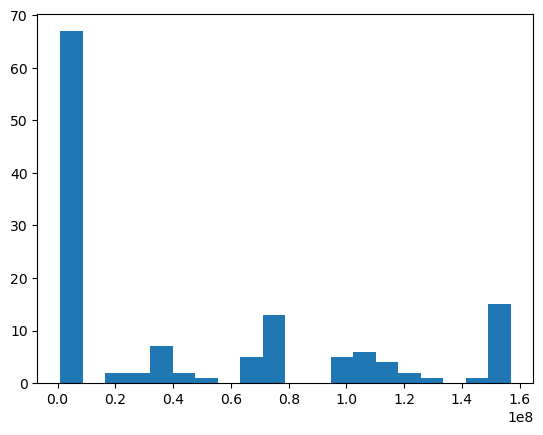

In [44]:
plt.hist(read_actb.query("taps_chrom == 'chr7'").taps_start_1based, bins=20)

(array([ 9., 13., 20.,  3.,  1.,  2.,  0.,  0.,  9.,  6.,  0.,  2., 82.,
         8.,  5.,  1.,  2., 26., 18.,  9.]),
 array([1.30545200e+06, 1.36295277e+07, 2.59536034e+07, 3.82776791e+07,
        5.06017548e+07, 6.29258305e+07, 7.52499062e+07, 8.75739819e+07,
        9.98980576e+07, 1.12222133e+08, 1.24546209e+08, 1.36870285e+08,
        1.49194360e+08, 1.61518436e+08, 1.73842512e+08, 1.86166588e+08,
        1.98490663e+08, 2.10814739e+08, 2.23138815e+08, 2.35462890e+08,
        2.47786966e+08]),
 <BarContainer object of 20 artists>)

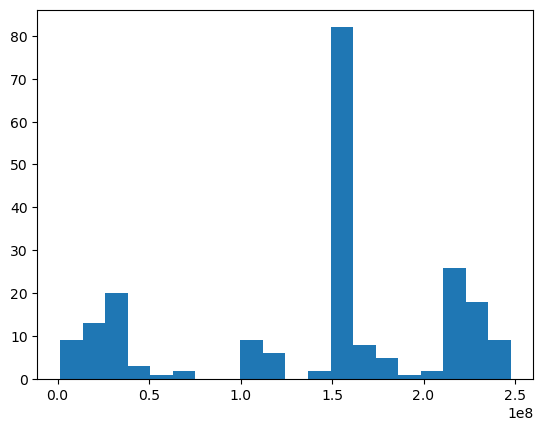

In [49]:
plt.hist(read_actb.query("taps_chrom == 'chr1'").taps_start_1based, bins=20)

(array([ 0.,  9.,  4.,  1.,  1.,  0.,  0.,  0.,  0.,  2.,  4., 75.,  3.,
         3.,  5.,  4.,  1.,  0.,  0.,  1.]),
 array([1.00e+08, 1.05e+08, 1.10e+08, 1.15e+08, 1.20e+08, 1.25e+08,
        1.30e+08, 1.35e+08, 1.40e+08, 1.45e+08, 1.50e+08, 1.55e+08,
        1.60e+08, 1.65e+08, 1.70e+08, 1.75e+08, 1.80e+08, 1.85e+08,
        1.90e+08, 1.95e+08, 2.00e+08]),
 <BarContainer object of 20 artists>)

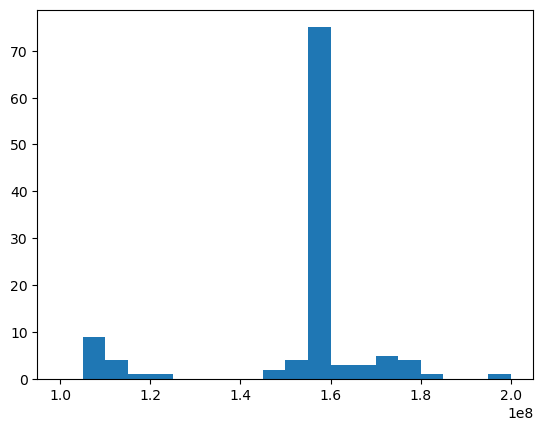

In [50]:
plt.hist(read_actb.query("taps_chrom == 'chr1'").taps_start_1based, bins=20, range=(1e8, 2e8))

In [51]:
read_actb.query("taps_chrom == 'chr1'")

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,...,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
5926075,AAATGAATTGGAGGGGG,AAA,TGAATTGGAGGGGG,VH01570:206:AAJ2NL3M5:1:2302:53811:51718_CATGC...,CATGCGCT,CATGCGCTAAATGAATTGGAGGGGG,chr7,5530005,5530034,+,...,VH01570:206:AAJ2NL3M5:1:1605:54360:38334|METH_...,CGGACCCA,CGGACCCAAAATGAATTGGAGGGGG,chr1,43366389,43366435,-,42,47M,read1
5926100,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2502:39363:32995_TATGC...,TATGCTAC,TATGCTACAAATGAAGGGAGGGAAT,chr7,5530015,5530042,-,...,VH01570:206:AAJ2NL3M5:1:2102:62332:39905|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
5926101,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2502:39363:32995_TATGC...,TATGCTAC,TATGCTACAAATGAAGGGAGGGAAT,chr7,5530015,5530042,-,...,VH01570:206:AAJ2NL3M5:1:2211:23855:30098|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
5926102,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2502:39363:32995_TATGC...,TATGCTAC,TATGCTACAAATGAAGGGAGGGAAT,chr7,5530015,5530042,-,...,VH01570:206:AAJ2NL3M5:1:2405:41049:25895|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
5926103,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2502:39363:32995_TATGC...,TATGCTAC,TATGCTACAAATGAAGGGAGGGAAT,chr7,5530015,5530042,-,...,VH01570:206:AAJ2NL3M5:1:2606:39193:55808|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5927693,TGATATAGTAGAGATGA,TGA,TATAGTAGAGATGA,VH01570:206:AAJ2NL3M5:1:1604:63317:36611_CTGGC...,CTGGCAGG,CTGGCAGGTGATATAGTAGAGATGA,chr7,5530574,5530601,-,...,VH01570:206:AAJ2NL3M5:1:1505:39931:15312|METH_...,TTTCTTCA,TTTCTTCATGATATAGTAGAGATGA,chr1,173141696,173141742,+,42,47M,read1
5927696,TGATATAGTAGAGATGA,TGA,TATAGTAGAGATGA,VH01570:206:AAJ2NL3M5:1:1510:31410:9784_ATGCAT...,ATGCATCT,ATGCATCTTGATATAGTAGAGATGA,chr7,5530574,5530601,-,...,VH01570:206:AAJ2NL3M5:1:1505:39931:15312|METH_...,TTTCTTCA,TTTCTTCATGATATAGTAGAGATGA,chr1,173141696,173141742,+,42,47M,read1
5927699,TGATATAGTAGAGATGA,TGA,TATAGTAGAGATGA,VH01570:206:AAJ2NL3M5:1:2608:60950:16297_CAATT...,CAATTAGC,CAATTAGCTGATATAGTAGAGATGA,chr7,5530574,5530601,-,...,VH01570:206:AAJ2NL3M5:1:1505:39931:15312|METH_...,TTTCTTCA,TTTCTTCATGATATAGTAGAGATGA,chr1,173141696,173141742,+,42,47M,read1
5927702,TGATATAGTAGAGATGA,TGA,TATAGTAGAGATGA,VH01570:206:AAJ2NL3M5:1:1608:76174:32048_TTATT...,TTATTACT,TTATTACTTGATATAGTAGAGATGA,chr7,5530574,5530600,-,...,VH01570:206:AAJ2NL3M5:1:1505:39931:15312|METH_...,TTTCTTCA,TTTCTTCATGATATAGTAGAGATGA,chr1,173141696,173141742,+,42,47M,read1


In [54]:
read_actb.query("taps_chrom == 'chr1'").iloc[1].taps_read_id

'VH01570:206:AAJ2NL3M5:1:2102:62332:39905|METH_CODE=AAA|METH_LABEL=0%|METH_EXPECTED=0|R2=AAATGAAGGGAGGGAAT|UMI=CTCACAACAAATGAAGGGAGGGAAT'

In [ ]:
results/taps_pipeline/TAPS_27ac_rep1_S7_paired_bowtie2/work/TAPS_27ac_rep1_S7.tagged.R1.fastq.gz
@VH01570:206:AAJ2NL3M5:1:2102:62332:39905|METH_CODE=AAA|METH_LABEL=0%|METH_EXPECTED=0|R2=AAATGAAGGGAGGGAAT|UMI=CTCACAACAAATGAAGGGAGGGAAT
CCCTCCTGCGAGGCCTGCTCCCCACGCCCCTACTCCTGGGCCCCTCT
+
IIII9IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII
results/taps_pipeline/TAPS_27ac_rep1_S7_paired_bowtie2/work/TAPS_27ac_rep1_S7.tagged.R3.fastq.gz
@VH01570:206:AAJ2NL3M5:1:2102:62332:39905|METH_CODE=AAA|METH_LABEL=0%|METH_EXPECTED=0|R2=AAATGAAGGGAGGGAAT|UMI=CTCACAACAAATGAAGGGAGGGAAT
GAGAAGGAGACCCGAGAGGGGCCCAGGAGTAGGGGCGTGGGGAGCAGGCCTCGC
+
IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII9IIIIIIIII
results/taps_pipeline/TAPS_27ac_rep1_S7_paired_bowtie2/work/TAPS_27ac_rep1_S7.tagged.trim.R1.fastq.gz
@VH01570:206:AAJ2NL3M5:1:2102:62332:39905|METH_CODE=AAA|METH_LABEL=0%|METH_EXPECTED=0|R2=AAATGAAGGGAGGGAAT|UMI=CTCACAACAAATGAAGGGAGGGAAT
CCCTCCTGCGAGGCCTGCTCCCCACGCCCCTACTCCTGGGCCCCTCT
+
IIII9IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII
results/taps_pipeline/TAPS_27ac_rep1_S7_paired_bowtie2/work/TAPS_27ac_rep1_S7.tagged.trim.R3.fastq.gz
@VH01570:206:AAJ2NL3M5:1:2102:62332:39905|METH_CODE=AAA|METH_LABEL=0%|METH_EXPECTED=0|R2=AAATGAAGGGAGGGAAT|UMI=CTCACAACAAATGAAGGGAGGGAAT
GAGAAGGAGACCCGAGAGGGGCCCAGGAGTAGGGGCGTGGGGAGCAGGCCTCGC
+
IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII9IIIIIIIII

In [ ]:
/gpfs/data/zhou-lab/yczhang/methylation/data/Run202/TAPS_27ac_rep1_S7_R1_001.fastq.gz
@VH01570:206:AAJ2NL3M5:1:2102:62332:39905 1:N:0:CTTCGCCTGT
CTCACAACCCCTCCTGCGAGGCCTGCTCCCCACGCCCCTACTCCTGGGCCCCTCT
+
IIIIIIIIIIII9IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII
/gpfs/data/zhou-lab/yczhang/methylation/data/Run202/TAPS_27ac_rep1_S7_R2_001.fastq.gz
@VH01570:206:AAJ2NL3M5:1:2102:62332:39905 2:N:0:CTTCGCCTGT
AAATGAAGGGAGGGAAT
+
IIIIIIIIIIIIIIIII
/gpfs/data/zhou-lab/yczhang/methylation/data/Run202/TAPS_27ac_rep1_S7_R3_001.fastq.gz
@VH01570:206:AAJ2NL3M5:1:2102:62332:39905 3:N:0:CTTCGCCTGT
GAGAAGGAGACCCGAGAGGGGCCCAGGAGTAGGGGCGTGGGGAGCAGGCCTCGC
+
IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII9IIIIIIIII

In [57]:
read_taps = read_associated.query("taps_chrom == 'chr1' & ((taps_start_1based >= 156490176) & (taps_start_1based <= 156490196))")

In [60]:
read_taps

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,...,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
1444133,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2309:71989:34339_GCGTA...,GCGTAATA,GCGTAATAAAATGAAGGGAGGGAAT,chr11,119319799,119319824,-,...,VH01570:206:AAJ2NL3M5:1:2102:62332:39905|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
1444134,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2309:71989:34339_GCGTA...,GCGTAATA,GCGTAATAAAATGAAGGGAGGGAAT,chr11,119319799,119319824,-,...,VH01570:206:AAJ2NL3M5:1:2211:23855:30098|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
1444135,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2309:71989:34339_GCGTA...,GCGTAATA,GCGTAATAAAATGAAGGGAGGGAAT,chr11,119319799,119319824,-,...,VH01570:206:AAJ2NL3M5:1:2405:41049:25895|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
1444136,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2309:71989:34339_GCGTA...,GCGTAATA,GCGTAATAAAATGAAGGGAGGGAAT,chr11,119319799,119319824,-,...,VH01570:206:AAJ2NL3M5:1:2606:39193:55808|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
1444137,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2309:71989:34339_GCGTA...,GCGTAATA,GCGTAATAAAATGAAGGGAGGGAAT,chr11,119319799,119319824,-,...,VH01570:206:AAJ2NL3M5:1:2611:37697:22961|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6898153,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2102:19708:31291_TAGCT...,TAGCTTAG,TAGCTTAGAAATGAAGGGAGGGAAT,chrX,49166419,49166465,-,...,VH01570:206:AAJ2NL3M5:1:2102:62332:39905|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
6898154,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2102:19708:31291_TAGCT...,TAGCTTAG,TAGCTTAGAAATGAAGGGAGGGAAT,chrX,49166419,49166465,-,...,VH01570:206:AAJ2NL3M5:1:2211:23855:30098|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
6898155,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2102:19708:31291_TAGCT...,TAGCTTAG,TAGCTTAGAAATGAAGGGAGGGAAT,chrX,49166419,49166465,-,...,VH01570:206:AAJ2NL3M5:1:2405:41049:25895|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1
6898156,AAATGAAGGGAGGGAAT,AAA,TGAAGGGAGGGAAT,VH01570:206:AAJ2NL3M5:1:2102:19708:31291_TAGCT...,TAGCTTAG,TAGCTTAGAAATGAAGGGAGGGAAT,chrX,49166419,49166465,-,...,VH01570:206:AAJ2NL3M5:1:2606:39193:55808|METH_...,CTCACAAC,CTCACAACAAATGAAGGGAGGGAAT,chr1,156490186,156490232,+,42,47M,read1


In [63]:
read_associated.query("plasmid_barcode == 'TGAAGGGAGGGAAT'").groupby(by=['stap_chrom', 'stap_start_1based'], as_index=False).agg({'stap_read_id': 'count'}).sort_values(by='stap_read_id', ascending=False)

,stap_chrom,stap_start_1based,stap_read_id
21,chr7,5530015,126
5,chr16,69762363,28
1,chr15,64461265,14
2,chr16,21953153,14
3,chr16,28863272,14
0,chr11,119319799,14
6,chr16,69762367,14
7,chr16,69762370,14
8,chr16,69762384,14
9,chr16,69762385,14


In [64]:
read_associated.query("plasmid_barcode == 'TGAAGGGAGGGAAT'").groupby(by=['taps_chrom', 'taps_start_1based'], as_index=False).agg({'taps_read_id': 'count'}).sort_values(by='taps_read_id', ascending=False)

,taps_chrom,taps_start_1based,taps_read_id
1,chr16,69762319,273
0,chr1,156490186,195
2,chr16,87841869,39
3,chr9,105924225,39


In [69]:
pd.set_option('display.max_columns', None)

In [71]:
read_associated.query("plasmid_barcode == 'GAGTTGAGAAAGAG'")

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,stap_mapq,stap_cigar,stap_read_number,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
2630910,TAGGAGTTGAGAAAGAG,TAG,GAGTTGAGAAAGAG,VH01570:206:AAJ2NL3M5:1:2608:15694:10012_GCACT...,GCACTGTC,GCACTGTCTAGGAGTTGAGAAAGAG,chr17,714899,714945,+,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2408:17417:26047|METH_...,CGGAGGGA,CGGAGGGATAGGAGTTGAGAAAGAG,chr1,112955875,112955921,-,42,47M,read1
2630911,TAGGAGTTGAGAAAGAG,TAG,GAGTTGAGAAAGAG,VH01570:206:AAJ2NL3M5:1:2608:15694:10012_GCACT...,GCACTGTC,GCACTGTCTAGGAGTTGAGAAAGAG,chr17,714899,714945,+,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2309:27680:26577|METH_...,TGATGCCT,TGATGCCTTAGGAGTTGAGAAAGAG,chr5,179805478,179805524,+,42,47M,read1
3525259,TAGGAGTTGAGAAAGAG,TAG,GAGTTGAGAAAGAG,VH01570:206:AAJ2NL3M5:1:1607:34724:16846_GGAGA...,GGAGAGCG,GGAGAGCGTAGGAGTTGAGAAAGAG,chr19,38637257,38637303,-,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2408:17417:26047|METH_...,CGGAGGGA,CGGAGGGATAGGAGTTGAGAAAGAG,chr1,112955875,112955921,-,42,47M,read1
3525260,TAGGAGTTGAGAAAGAG,TAG,GAGTTGAGAAAGAG,VH01570:206:AAJ2NL3M5:1:1607:34724:16846_GGAGA...,GGAGAGCG,GGAGAGCGTAGGAGTTGAGAAAGAG,chr19,38637257,38637303,-,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2309:27680:26577|METH_...,TGATGCCT,TGATGCCTTAGGAGTTGAGAAAGAG,chr5,179805478,179805524,+,42,47M,read1
5201128,TAGGAGTTGAGAAAGAG,TAG,GAGTTGAGAAAGAG,VH01570:206:AAJ2NL3M5:1:1110:74224:20859_ACGGC...,ACGGCAGT,ACGGCAGTTAGGAGTTGAGAAAGAG,chr4,75724917,75724963,+,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2408:17417:26047|METH_...,CGGAGGGA,CGGAGGGATAGGAGTTGAGAAAGAG,chr1,112955875,112955921,-,42,47M,read1
5201129,TAGGAGTTGAGAAAGAG,TAG,GAGTTGAGAAAGAG,VH01570:206:AAJ2NL3M5:1:1110:74224:20859_ACGGC...,ACGGCAGT,ACGGCAGTTAGGAGTTGAGAAAGAG,chr4,75724917,75724963,+,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2309:27680:26577|METH_...,TGATGCCT,TGATGCCTTAGGAGTTGAGAAAGAG,chr5,179805478,179805524,+,42,47M,read1


In [77]:
stap_read_consistency = pd.read_csv("../results/standard_tools/STAP_TSS_27ac_rep1_S3_bowtie/STAP_TSS_27ac_rep1_S3.barcode_mapping_consistency.families.tsv", sep='\t')

In [78]:
stap_read_consistency

,meth_code,meth_label,expected_methylation,plasmid_barcode,r2_barcode,n_reads,n_unique_r1_umis,n_loci,major_locus,major_locus_reads,exact_consistency,exact_discordant_reads,window_locus,window_reads,window_consistency,window_discordant_reads,all_loci_counts
0,AAA,0%,0.0,AAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAA,6,6,6,chr8:+:94822856,1,0.166667,5,chr1:+:146039439,1,0.166667,5,chr1:+:146039439=1;chr11:+:119381094=1;chr15:+...
1,AAA,0%,0.0,AAAAAAAAAAAAGG,AAAAAAAAAAAAAAAGG,2,2,2,chr11:-:94973503,1,0.500000,1,chr11:+:64270276,1,0.500000,1,chr11:+:64270276=1;chr11:-:94973503=1
2,AAA,0%,0.0,AAAAAAAAAAAGGG,AAAAAAAAAAAAAAGGG,2,2,2,chr2:-:218397797,1,0.500000,1,chr17:-:56960720,1,0.500000,1,chr17:-:56960720=1;chr2:-:218397797=1
3,AAA,0%,0.0,AAAAAAAAAAGAGG,AAAAAAAAAAAAAGAGG,1,1,1,chr10:-:5479092,1,1.000000,0,chr10:-:5479092,1,1.000000,0,chr10:-:5479092=1
4,AAA,0%,0.0,AAAAAAAAAAGGAA,AAAAAAAAAAAAAGGAA,2,2,2,chr22:-:50464235,1,0.500000,1,chr2:+:177619018,1,0.500000,1,chr2:+:177619018=1;chr22:-:50464235=1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3960568,TTT,100%,1.0,TTTTTTTTGATATG,TTTTTTTTTTTGATATG,1,1,1,chr3:+:72310832,1,1.000000,0,chr3:+:72310832,1,1.000000,0,chr3:+:72310832=1
3960569,TTT,100%,1.0,TTTTTTTTGGGGGT,TTTTTTTTTTTGGGGGT,1,1,1,chr17:+:74737890,1,1.000000,0,chr17:+:74737890,1,1.000000,0,chr17:+:74737890=1
3960570,TTT,100%,1.0,TTTTTTTTTGATAT,TTTTTTTTTTTTGATAT,1,1,1,chr3:+:72310832,1,1.000000,0,chr3:+:72310832,1,1.000000,0,chr3:+:72310832=1
3960571,TTT,100%,1.0,TTTTTTTTTTTAGA,TTTTTTTTTTTTTTAGA,1,1,1,chr11:-:62593709,1,1.000000,0,chr11:-:62593709,1,1.000000,0,chr11:-:62593709=1


In [ ]:
read_associated_bismark = pd.read_csv("../results/stap_taps_association/STAP_TSS_27ac_rep1_S3_bowtie2_TAPS_27ac_rep1_S7_bismark_paired/stap_taps_read_associations.tsv.gz", sep='\t')

In [27]:
read_associated_bismark.shape

(6628900, 23)

In [28]:
read_associated_bismark.query("stap_chrom == taps_chrom")

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,...,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
15,CATGTGAGTTGTGGAGA,CAT,GTGAGTTGTGGAGA,VH01570:206:AAJ2NL3M5:1:2307:16982:25006_TAGAA...,TAGAAATG,TAGAAATGCATGTGAGTTGTGGAGA,chr1,136561,136607,-,...,VH01570:206:AAJ2NL3M5:1:2510:57674:43881|METH_...,AAAGTGCT,AAAGTGCTCATGTGAGTTGTGGAGA,chr1,114512033,114512087,-,42,55M,read1
20,CTATGGAAAGAGTTTAG,CTA,TGGAAAGAGTTTAG,VH01570:206:AAJ2NL3M5:1:2409:40859:12567_TAGAA...,TAGAAATG,TAGAAATGCTATGGAAAGAGTTTAG,chr1,136561,136607,-,...,VH01570:206:AAJ2NL3M5:1:1209:58602:19780|METH_...,AGCCAGGA,AGCCAGGACTATGGAAAGAGTTTAG,chr1,181112477,181112531,-,42,55M,read1
21,AAAGTGAATAAGGAGTG,AAA,GTGAATAAGGAGTG,VH01570:206:AAJ2NL3M5:1:2604:17512:10504_GCAGC...,GCAGCCTA,GCAGCCTAAAAGTGAATAAGGAGTG,chr1,136879,136910,-,...,VH01570:206:AAJ2NL3M5:1:1604:52145:36573|METH_...,TGGTACAT,TGGTACATAAAGTGAATAAGGAGTG,chr1,21163181,21163235,-,42,55M,read1
22,AAAGTGAATAAGGAGTG,AAA,GTGAATAAGGAGTG,VH01570:206:AAJ2NL3M5:1:2604:17512:10504_GCAGC...,GCAGCCTA,GCAGCCTAAAAGTGAATAAGGAGTG,chr1,136879,136910,-,...,VH01570:206:AAJ2NL3M5:1:2405:23817:1473|METH_C...,TGGTACAT,TGGTACATAAAGTGAATAAGGAGTG,chr1,21163181,21163235,-,42,55M,read1
30,CATTAAGGGAGGAGGGG,CAT,TAAGGGAGGAGGGG,VH01570:206:AAJ2NL3M5:1:2311:37148:52665_TGCCT...,TGCCTCCG,TGCCTCCGCATTAAGGGAGGAGGGG,chr1,137099,137145,+,...,VH01570:206:AAJ2NL3M5:1:1403:68202:17793|METH_...,CTCAGGGA,CTCAGGGACATTAAGGGAGGAGGGG,chr1,225925361,225925415,-,42,55M,read1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6628567,TAGTGTGAGTATAGTGG,TAG,TGTGAGTATAGTGG,VH01570:206:AAJ2NL3M5:1:2602:9483:17811_CAACAC...,CAACACTA,CAACACTATAGTGTGAGTATAGTGG,chrX,155612593,155612639,+,...,VH01570:206:AAJ2NL3M5:1:2508:62502:35645|METH_...,GCTAGGCC,GCTAGGCCTAGTGTGAGTATAGTGG,chrX,155612530,155612584,+,42,55M,read1
6628571,AAATTGTGTAGTTGGAG,AAA,TTGTGTAGTTGGAG,VH01570:206:AAJ2NL3M5:1:2201:54038:28659_ATCAG...,ATCAGTAA,ATCAGTAAAAATTGTGTAGTTGGAG,chrX,155612626,155612672,+,...,VH01570:206:AAJ2NL3M5:1:1301:73125:46455|METH_...,CCCATCCG,CCCATCCGAAATTGTGTAGTTGGAG,chrX,155612536,155612590,+,42,55M,read1
6628576,ATGGTGGAGAAATGGGT,ATG,GTGGAGAAATGGGT,VH01570:206:AAJ2NL3M5:1:2610:36353:41306_TTGCC...,TTGCCTAT,TTGCCTATATGGTGGAGAAATGGGT,chrX,155612912,155612958,-,...,VH01570:206:AAJ2NL3M5:1:1204:68959:44903|METH_...,CGGCCCAG,CGGCCCAGATGGTGGAGAAATGGGT,chrX,155613004,155613058,-,40,55M,read1
6628587,TAGTGAAATGAAGGGGA,TAG,TGAAATGAAGGGGA,VH01570:206:AAJ2NL3M5:1:1511:63525:11753_GGCAC...,GGCACAGT,GGCACAGTTAGTGAAATGAAGGGGA,chrX,155612968,155613013,+,...,VH01570:206:AAJ2NL3M5:1:1202:31865:29208|METH_...,CCACGCTC,CCACGCTCTAGTGAAATGAAGGGGA,chrX,155612909,155612963,+,40,55M,read1


In [29]:
read_actb_bismark = read_associated_bismark.query("stap_chrom == 'chr7' & ((stap_start_1based >= 5530000) & (stap_start_1based <= 5531000))")

In [31]:
read_actb_bismark.shape

(1587, 23)

In [32]:
read_actb_bismark.query("taps_chrom == 'chr7'")

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,...,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
5644852,TGAGTATTGTGTAGAGG,TGA,GTATTGTGTAGAGG,VH01570:206:AAJ2NL3M5:1:2609:46635:2817_CCAGCA...,CCAGCACA,CCAGCACATGAGTATTGTGTAGAGG,chr7,5530017,5530042,-,...,VH01570:206:AAJ2NL3M5:1:2403:42355:25990|METH_...,GCTAATTG,GCTAATTGTGAGTATTGTGTAGAGG,chr7,5530067,5530121,-,40,55M,read1
5644853,ATGGGGTGGTGAGAGTG,ATG,GGGTGGTGAGAGTG,VH01570:206:AAJ2NL3M5:1:2411:22586:30344_TCCCA...,TCCCAAGA,TCCCAAGAATGGGGTGGTGAGAGTG,chr7,5530017,5530049,-,...,VH01570:206:AAJ2NL3M5:1:2201:48509:1360|METH_C...,ATTGCGCG,ATTGCGCGATGGGGTGGTGAGAGTG,chr7,5530123,5530177,-,42,55M,read1
5644855,TGAGTATTGTGTAGAGG,TGA,GTATTGTGTAGAGG,VH01570:206:AAJ2NL3M5:1:2610:63279:44259_TTCTC...,TTCTCCAA,TTCTCCAATGAGTATTGTGTAGAGG,chr7,5530017,5530052,-,...,VH01570:206:AAJ2NL3M5:1:2403:42355:25990|METH_...,GCTAATTG,GCTAATTGTGAGTATTGTGTAGAGG,chr7,5530067,5530121,-,40,55M,read1
5644863,TAGGGAGGGGATAGGTT,TAG,GGAGGGGATAGGTT,VH01570:206:AAJ2NL3M5:1:1111:33493:8535_CTTCAG...,CTTCAGGC,CTTCAGGCTAGGGAGGGGATAGGTT,chr7,5530020,5530066,+,...,VH01570:206:AAJ2NL3M5:1:2306:70929:15861|METH_...,AAGCGCCC,AAGCGCCCTAGGGAGGGGATAGGTT,chr7,5529987,5530041,+,40,55M,read1
5644875,ATGATTGAATGTGGGGG,ATG,ATTGAATGTGGGGG,VH01570:206:AAJ2NL3M5:1:1507:32452:51529_TTCCT...,TTCCTAGC,TTCCTAGCATGATTGAATGTGGGGG,chr7,5530026,5530059,+,...,VH01570:206:AAJ2NL3M5:1:1504:43397:46342|METH_...,GCAGCGGC,GCAGCGGCATGATTGAATGTGGGGG,chr7,5529937,5529991,+,42,55M,read1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5645976,ATGAGTGTGGAAGGGAA,ATG,AGTGTGGAAGGGAA,VH01570:206:AAJ2NL3M5:1:1408:39837:51832_TTTTC...,TTTTCATG,TTTTCATGATGAGTGTGGAAGGGAA,chr7,5530562,5530601,-,...,VH01570:206:AAJ2NL3M5:1:2404:59567:33922|METH_...,TAGAGGAA,TAGAGGAAATGAGTGTGGAAGGGAA,chr7,101856612,101856666,-,42,55M,read1
5645983,AGTTGGATGATGAGAGA,AGT,TGGATGATGAGAGA,VH01570:206:AAJ2NL3M5:1:2208:66290:27656_TTTTC...,TTTTCATG,TTTTCATGAGTTGGATGATGAGAGA,chr7,5530562,5530601,-,...,VH01570:206:AAJ2NL3M5:1:1102:40253:5752|METH_C...,GGAGCAGG,GGAGCAGGAGTTGGATGATGAGAGA,chr7,32662351,32662405,-,42,55M,read1
5645988,TAGGAGAGGGGAGGGGT,TAG,GAGAGGGGAGGGGT,VH01570:206:AAJ2NL3M5:1:2608:29782:1341_TTTTCA...,TTTTCATG,TTTTCATGTAGGAGAGGGGAGGGGT,chr7,5530562,5530601,-,...,VH01570:206:AAJ2NL3M5:1:2304:51425:4540|METH_C...,AGCAGCAG,AGCAGCAGTAGGAGAGGGGAGGGGT,chr7,150952732,150952786,+,42,55M,read1
5646139,AAAGAAAGTAGTAGGTA,AAA,GAAAGTAGTAGGTA,VH01570:206:AAJ2NL3M5:1:1403:21450:44619_TTAAT...,TTAATCGA,TTAATCGAAAAGAAAGTAGTAGGTA,chr7,5530569,5530601,-,...,VH01570:206:AAJ2NL3M5:1:2505:35766:7967|METH_C...,CTCAGTGG,CTCAGTGGAAAGAAAGTAGTAGGTA,chr7,75915119,75915173,+,40,55M,read1


(array([34.,  3.,  9.,  1., 18.,  0., 11.,  9.,  1., 16.]),
 array([1.02786500e+06, 1.66199831e+07, 3.22121012e+07, 4.78042193e+07,
        6.33963374e+07, 7.89884555e+07, 9.45805736e+07, 1.10172692e+08,
        1.25764810e+08, 1.41356928e+08, 1.56949046e+08]),
 <BarContainer object of 10 artists>)

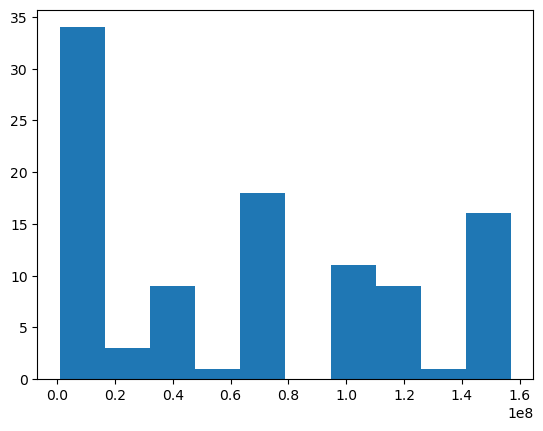

In [34]:
plt.hist(read_actb_bismark.query("taps_chrom == 'chr7'").taps_start_1based)

In [ ]:
read_associated_bas = pd.read_csv("../results/stap_taps_association/STAP_TSS_BasPromoter_S6_bowtie_TAPS_BasPromoter_S10_paired_bowtie2/stap_taps_read_associations.tsv.gz", sep='\t')

In [74]:
pd.set_option('display.max_rows', 20)

In [75]:
read_associated_bas

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,stap_mapq,stap_cigar,stap_read_number,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
0,ATGGAGGAAGTGTGTAA,ATG,GAGGAAGTGTGTAA,VH01570:206:AAJ2NL3M5:1:1411:63317:20746_TTGGA...,TTGGAAAA,TTGGAAAAATGGAGGAAGTGTGTAA,chr1,778586,778632,-,25,47M,read1,VH01570:206:AAJ2NL3M5:1:2311:11055:31121|METH_...,TTCCCCGG,TTCCCCGGATGGAGGAAGTGTGTAA,chr5,79513947,79513993,+,42,47M,read1
1,ATGGAGGAAGTGTGTAA,ATG,GAGGAAGTGTGTAA,VH01570:206:AAJ2NL3M5:1:2108:15334:20292_CCACT...,CCACTATA,CCACTATAATGGAGGAAGTGTGTAA,chr1,778588,778634,-,25,47M,read1,VH01570:206:AAJ2NL3M5:1:2311:11055:31121|METH_...,TTCCCCGG,TTCCCCGGATGGAGGAAGTGTGTAA,chr5,79513947,79513993,+,42,47M,read1
2,ATGGAGGAAGTGTGTAA,ATG,GAGGAAGTGTGTAA,VH01570:206:AAJ2NL3M5:1:2106:31619:53081_GTACC...,GTACCGTC,GTACCGTCATGGAGGAAGTGTGTAA,chr1,778601,778647,-,37,47M,read1,VH01570:206:AAJ2NL3M5:1:2311:11055:31121|METH_...,TTCCCCGG,TTCCCCGGATGGAGGAAGTGTGTAA,chr5,79513947,79513993,+,42,47M,read1
3,ATGGAGGAAGTGTGTAA,ATG,GAGGAAGTGTGTAA,VH01570:206:AAJ2NL3M5:1:2501:43245:19610_CTAGC...,CTAGCATG,CTAGCATGATGGAGGAAGTGTGTAA,chr1,778611,778657,-,38,47M,read1,VH01570:206:AAJ2NL3M5:1:2311:11055:31121|METH_...,TTCCCCGG,TTCCCCGGATGGAGGAAGTGTGTAA,chr5,79513947,79513993,+,42,47M,read1
4,ATGGAGGAAGTGTGTAA,ATG,GAGGAAGTGTGTAA,VH01570:206:AAJ2NL3M5:1:1308:29365:5279_GACATG...,GACATGCC,GACATGCCATGGAGGAAGTGTGTAA,chr1,778614,778660,-,38,47M,read1,VH01570:206:AAJ2NL3M5:1:2311:11055:31121|METH_...,TTCCCCGG,TTCCCCGGATGGAGGAAGTGTGTAA,chr5,79513947,79513993,+,42,47M,read1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19547,AAAATGATAAGGGAGTG,AAA,ATGATAAGGGAGTG,VH01570:206:AAJ2NL3M5:1:2204:49513:38674_TTTTT...,TTTTTTCC,TTTTTTCCAAAATGATAAGGGAGTG,chrX,154379292,154379338,-,21,47M,read1,VH01570:206:AAJ2NL3M5:1:1405:17644:31121|METH_...,CTGGATCC,CTGGATCCAAAATGATAAGGGAGTG,chr17,28580738,28580784,+,42,47M,read1
19548,ATGGTTATTAAGTTTTT,ATG,GTTATTAAGTTTTT,VH01570:206:AAJ2NL3M5:1:1607:44287:21939_AGGTC...,AGGTCTGA,AGGTCTGAATGGTTATTAAGTTTTT,chrX,154479145,154479191,-,44,47M,read1,VH01570:206:AAJ2NL3M5:1:1402:58734:42252|METH_...,CGCCTGTT,CGCCTGTTATGGTTATTAAGTTTTT,chr20,47241422,47241468,-,42,47M,read1
19549,TAGGGGAAGAAGGGTTA,TAG,GGGAAGAAGGGTTA,VH01570:206:AAJ2NL3M5:1:2401:29479:25914_CTTCA...,CTTCAGCC,CTTCAGCCTAGGGGAAGAAGGGTTA,chrX,154479338,154479384,+,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2506:67634:34528|METH_...,ATGGGGAA,ATGGGGAATAGGGGAAGAAGGGTTA,chr6,39227781,39227827,+,42,47M,read1
19550,TAGGGGAAGAAGGGTTA,TAG,GGGAAGAAGGGTTA,VH01570:206:AAJ2NL3M5:1:2301:59283:31064_CATGC...,CATGCAAA,CATGCAAATAGGGGAAGAAGGGTTA,chrX,154479403,154479449,+,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2506:67634:34528|METH_...,ATGGGGAA,ATGGGGAATAGGGGAAGAAGGGTTA,chr6,39227781,39227827,+,42,47M,read1


In [76]:
read_associated_bas.query("stap_chrom == taps_chrom")

,r2_barcode,meth_code,plasmid_barcode,stap_read_id,stap_r1_umi,stap_molecule_umi,stap_chrom,stap_start_1based,stap_end_1based,stap_strand,stap_mapq,stap_cigar,stap_read_number,taps_read_id,taps_r1_umi,taps_molecule_umi,taps_chrom,taps_start_1based,taps_end_1based,taps_strand,taps_mapq,taps_cigar,taps_read_number
21,AAAAGGAGTTGGAAGGA,AAA,AGGAGTTGGAAGGA,VH01570:206:AAJ2NL3M5:1:2208:32490:41192_AGAGT...,AGAGTGCA,AGAGTGCAAAAAGGAGTTGGAAGGA,chr1,1575305,1575351,+,44,47M,read1,VH01570:206:AAJ2NL3M5:1:1608:20068:12037|METH_...,ACTGACTC,ACTGACTCAAAAGGAGTTGGAAGGA,chr1,8702888,8702934,+,42,47M,read1
22,CATGGGAGGAAAAGAAT,CAT,GGGAGGAAAAGAAT,VH01570:206:AAJ2NL3M5:1:1501:61044:22791_CGGTC...,CGGTCATG,CGGTCATGCATGGGAGGAAAAGAAT,chr1,1615668,1615714,-,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2201:73542:31007|METH_...,GTGGTTGA,GTGGTTGACATGGGAGGAAAAGAAT,chr1,16318842,16318888,-,42,47M,read1
23,CATGGGAGGAAAAGAAT,CAT,GGGAGGAAAAGAAT,VH01570:206:AAJ2NL3M5:1:2205:35482:12492_TTGCT...,TTGCTTAA,TTGCTTAACATGGGAGGAAAAGAAT,chr1,1615688,1615734,-,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2201:73542:31007|METH_...,GTGGTTGA,GTGGTTGACATGGGAGGAAAAGAAT,chr1,16318842,16318888,-,42,47M,read1
24,CATGGGAGGAAAAGAAT,CAT,GGGAGGAAAAGAAT,VH01570:206:AAJ2NL3M5:1:2603:67274:13874_GGTTC...,GGTTCCTC,GGTTCCTCCATGGGAGGAAAAGAAT,chr1,1615696,1615742,-,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2201:73542:31007|METH_...,GTGGTTGA,GTGGTTGACATGGGAGGAAAAGAAT,chr1,16318842,16318888,-,42,47M,read1
25,CATGGGAGGAAAAGAAT,CAT,GGGAGGAAAAGAAT,VH01570:206:AAJ2NL3M5:1:2506:9710:16183_TCCACT...,TCCACTAA,TCCACTAACATGGGAGGAAAAGAAT,chr1,1615699,1615745,-,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2201:73542:31007|METH_...,GTGGTTGA,GTGGTTGACATGGGAGGAAAAGAAT,chr1,16318842,16318888,-,42,47M,read1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19341,ATGTAAAATTAAAGTTG,ATG,TAAAATTAAAGTTG,VH01570:206:AAJ2NL3M5:1:1311:68164:49598_ATCAG...,ATCAGCAC,ATCAGCACATGTAAAATTAAAGTTG,chrX,55717749,55717795,+,44,47M,read1,VH01570:206:AAJ2NL3M5:1:2403:8820:31499|METH_C...,GATGGTGT,GATGGTGTATGTAAAATTAAAGTTG,chrX,134782332,134782378,+,42,47M,read1
19342,ATGTAAAATTAAAGTTG,ATG,TAAAATTAAAGTTG,VH01570:206:AAJ2NL3M5:1:2204:44419:29379_TTTTC...,TTTTCAAC,TTTTCAACATGTAAAATTAAAGTTG,chrX,55717770,55717811,+,42,42M5S,read1,VH01570:206:AAJ2NL3M5:1:2403:8820:31499|METH_C...,GATGGTGT,GATGGTGTATGTAAAATTAAAGTTG,chrX,134782332,134782378,+,42,47M,read1
19343,ATGTAAAATTAAAGTTG,ATG,TAAAATTAAAGTTG,VH01570:206:AAJ2NL3M5:1:2402:33171:55770_CTTCC...,CTTCCCCA,CTTCCCCAATGTAAAATTAAAGTTG,chrX,55717770,55717811,+,41,42M5S,read1,VH01570:206:AAJ2NL3M5:1:2403:8820:31499|METH_C...,GATGGTGT,GATGGTGTATGTAAAATTAAAGTTG,chrX,134782332,134782378,+,42,47M,read1
19362,CTAAATGTAGTAAAGGG,CTA,AATGTAGTAAAGGG,VH01570:206:AAJ2NL3M5:1:1111:11206:37141_TTGCT...,TTGCTACG,TTGCTACGCTAAATGTAGTAAAGGG,chrX,71533109,71533155,+,42,47M,read1,VH01570:206:AAJ2NL3M5:1:2109:35747:16089|METH_...,TTGCTACG,TTGCTACGCTAAATGTAGTAAAGGG,chrX,71533109,71533155,+,23,47M,read1
